In [37]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, SVR
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
import seaborn as sns


In [4]:
df_train = pd.read_csv('/content/datos/mnist_train_tarea.txt', header=None)
df_test = pd.read_csv('/content/datos/mnist_test_clase.txt', header=None)

X_train = df_train.iloc[:, 1:]
y_train = df_train.iloc[:, 0]

X_test = df_test.iloc[:, 1:]
y_test = df_test.iloc[:, 0]


In [5]:
df_train.shape

(12001, 785)

In [6]:
df_test.shape

(501, 785)

Sin Tunning

In [7]:
SVC_model = Pipeline([('scaler', StandardScaler()), ('SVC', SVC())])

In [8]:
SVC_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('SVC', SVC())])

In [9]:
y_predic_SVC_sinTuning = SVC_model.predict(X_test)

In [10]:
print(f'Accuracy SVC Sin Tuning: {accuracy_score(y_test, y_predic_SVC_sinTuning)}')

Accuracy SVC Sin Tuning: 0.93812375249501


Con Tunning

In [23]:
param_grid = [
    {'SVC__C': [1, 5, 10], 'SVC__kernel': ['rbf']},
    {'SVC__C': [1, 5, 10], 'SVC__kernel': ['poly'], 'SVC__degree': [2, 3]}
]
grid_SVC = GridSearchCV(SVC_model, param_grid=param_grid, cv=5, n_jobs=-1)

In [24]:
X_tune = X_train[:5000]
y_tune = y_train[:5000]

grid_SVC.fit(X_tune, y_tune)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('SVC', SVC())]),
             n_jobs=-1,
             param_grid=[{'SVC__C': [1, 5, 10], 'SVC__kernel': ['rbf']},
                         {'SVC__C': [1, 5, 10], 'SVC__degree': [2, 3],
                          'SVC__kernel': ['poly']}])

In [25]:
grid_SVC.best_params_

{'SVC__C': 10, 'SVC__degree': 2, 'SVC__kernel': 'poly'}

In [26]:
tunned_SVC_model = Pipeline([('scaler', StandardScaler()), ('SVC', SVC(C=10, kernel='poly', degree=2))])

In [27]:
tunned_SVC_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('SVC', SVC(C=10, degree=2, kernel='poly'))])

In [28]:
y_predic_SVC_tunned = tunned_SVC_model.predict(X_test)

In [29]:
print(f'Accuracy SVC Con Tuning: {accuracy_score(y_test, y_predic_SVC_tunned)}')

Accuracy SVC Con Tuning: 0.9481037924151696


Probar con mis numeros

In [32]:
df_mn = pd.read_csv('/content/datos/mis_numeros_Carlos_Chavarria.csv', header=None)
df_mn

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [33]:
X_mn = df_mn.iloc[:,1:]
y_mn = df_mn.iloc[:,0]

In [35]:
y_pred_mn = tunned_SVC_model.predict(X_mn)
y_pred_mn

array([8, 1, 4, 1, 4, 5, 2, 9, 8, 9])

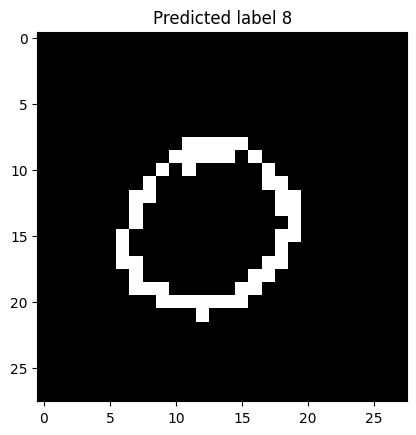

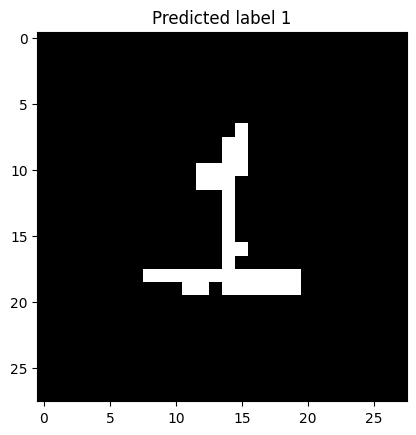

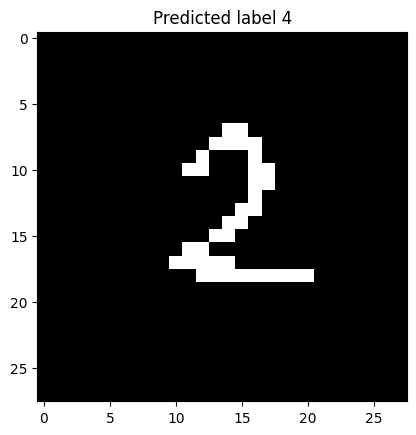

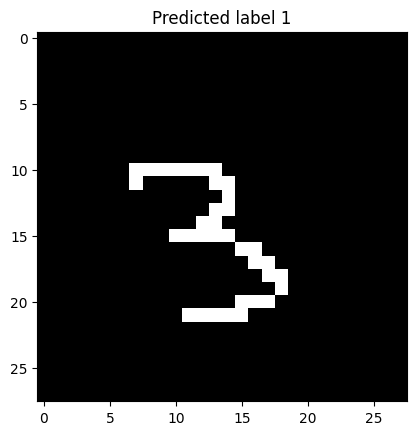

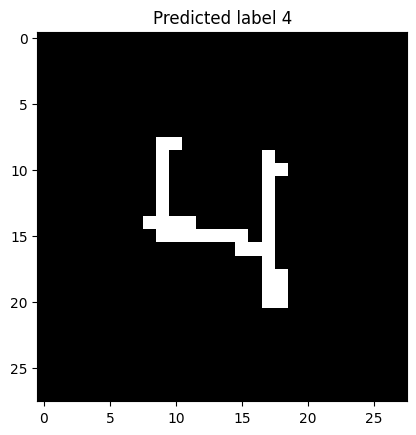

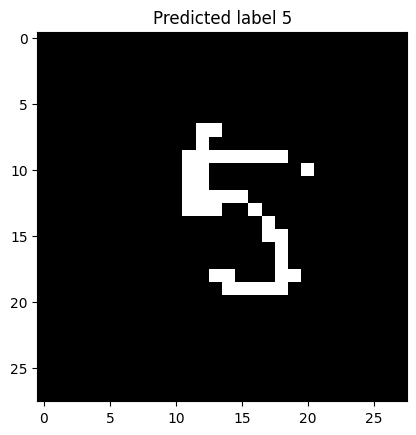

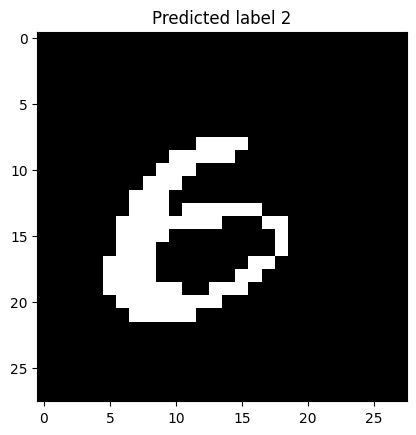

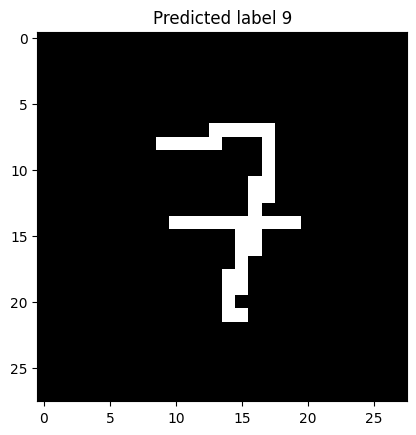

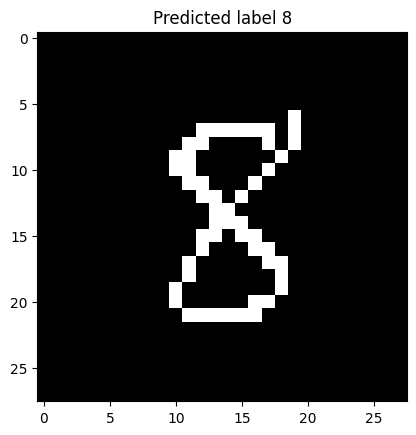

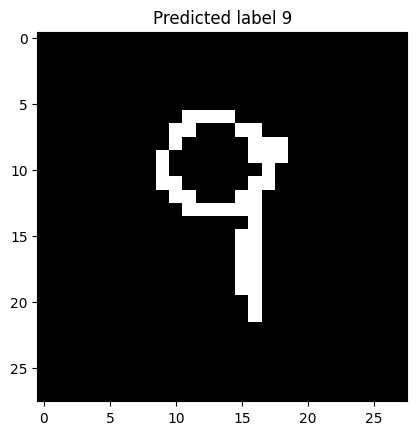

In [36]:
for i in range(10):
    img=X_mn.values[i].reshape((28,28))
    plt.title('Predicted label {0}'.format(y_pred_mn[i]))
    plt.imshow(img,cmap='gray')
    plt.show()

<Axes: xlabel='Predicted', ylabel='Actual'>

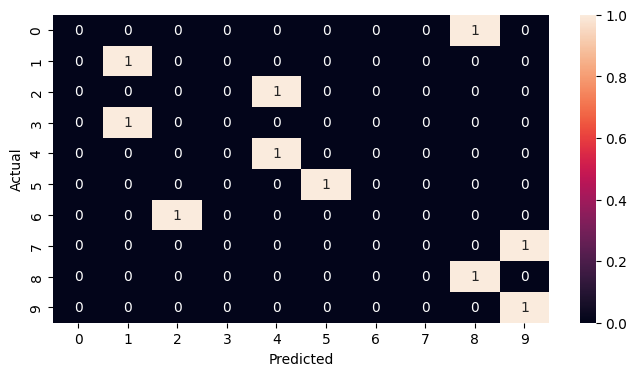

In [38]:
array=confusion_matrix(y_mn,y_pred_mn)
df_cm=pd.DataFrame(array,index=[i for i in range(10)],
                  columns=[i for i in range(10)])
df_cm.index.name='Actual'
df_cm.columns.name='Predicted'
plt.figure(figsize=(8,4))
sns.heatmap(df_cm, annot=True)

Datos de evaluacion

In [42]:
evaluacion = pd.read_csv('/content/datos/mnist_evaluacion_pixeles.txt', header=None)
evaluacion

,0,1,2,3,4,5,6,7,8,9,...,774,775,776,777,778,779,780,781,782,783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
496,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
497,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
498,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
499,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [43]:
prediccion_eval = tunned_SVC_model.predict(evaluacion)
prediccion_eval

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 1, 0,
       1, 2, 7, 5, 3, 4, 4, 0, 0, 6, 9, 6, 6, 5, 7, 0, 3, 4, 4, 9, 1, 4,
       0, 7, 9, 5, 7, 2, 3, 1, 4, 4, 0, 9, 9, 6, 1, 8, 3, 3, 7, 3, 9, 8,
       8, 4, 7, 7, 6, 2, 1, 9, 8, 7, 8, 8, 7, 2, 2, 3, 9, 3, 3, 5, 5, 0,
       7, 4, 5, 6, 5, 1, 4, 1, 1, 2, 2, 2, 6, 1, 5, 0, 1, 2, 3, 4, 5, 6,
       7, 8, 9, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 0, 1, 2, 3, 4, 5, 6, 7, 8,
       8, 0, 6, 0, 7, 2, 3, 7, 9, 4, 7, 1, 7, 1, 7, 1, 4, 0, 0, 1, 7, 5,
       7, 1, 3, 3, 3, 1, 6, 9, 7, 1, 3, 0, 2, 6, 0, 8, 9, 4, 3, 5, 4, 8,
       1, 5, 9, 0, 6, 3, 3, 8, 1, 4, 7, 5, 2, 0, 0, 1, 7, 8, 9, 6, 8, 8,
       2, 3, 6, 1, 5, 9, 5, 2, 0, 1, 2, 3, 4, 5, 6, 7, 5, 9, 0, 1, 2, 3,
       4, 0, 6, 7, 8, 9, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 7, 4, 6, 1, 4, 0,
       9, 9, 3, 7, 8, 5, 7, 5, 8, 5, 3, 2, 2, 0, 5, 5, 6, 0, 3, 8, 1, 0,
       3, 0, 4, 7, 4, 9, 0, 9, 0, 7, 1, 7, 1, 6, 6, 5, 6, 0, 5, 7, 5, 4,
       9, 9, 5, 3, 7, 4, 3, 0, 4, 6, 6, 1, 1, 3, 2,

In [50]:
np.savetxt('Carlos_Chavarria.txt', prediccion_eval, fmt='%d', delimiter=',')

In [51]:
pd.read_csv('Carlos_Chavarria.txt', header=None)

,0
0,0
1,1
2,2
3,3
4,4
...,...
496,1
497,2
498,3
499,4
